In [2]:
from copy import copy
from itertools import combinations

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

from scipy.stats import mannwhitneyu

sns.set_theme()
warnings.filterwarnings('ignore')

In [3]:
baselines_df1 = pd.read_csv("baselines.csv")
baselines_df2 = pd.read_csv("baselines_tinygp.csv")
baselines_df = pd.concat([baselines_df1, baselines_df2], ignore_index=True)

In [4]:
problems = ["chemical_2_competition", "friction_dyn_one-hot", "friction_stat_one-hot",
            "nasa_battery_1_10min", "nasa_battery_2_20min", "nikuradse_1",
            "nikuradse_2", ]  #"chemical_1_tower","flow_stress_phip0.1", ]

In [5]:
dfs = []
missing = 0
missing_configs = []
for problem in problems:
    tmp_df = pd.read_csv(f"../results/ridge_{problem}.csv")
    tmp_df["seed"] = 0
    tmp_df["problem"] = problem
    tmp_df["algo"] = "ridge"
    tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
    dfs.append(tmp_df)
    for seed in range(30):
        for extra in ['linscal', 'feats', 'featsls', 'baseline']:
            if os.path.exists(f"../results/CGP_{extra}_{problem}_{seed}.pickle"):
                tmp_df = pd.read_csv(f"../results/CGP_{extra}_{problem}_{seed}.csv")
                tmp_df["seed"] = seed
                tmp_df["problem"] = problem
                tmp_df["algo"] = f"CGP \n {extra}"
                tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
                dfs.append(tmp_df)
df = pd.concat(dfs, ignore_index=True)
df["test_accuracy"] = df["test_accuracy"].str.replace(r"[\[\]]", "", regex=True).astype(float)
df.head()

,iteration,max_fitness,time,test_accuracy,seed,problem,algo,total_time
0,1499,-0.921519,0.000000,-1.450991,0,chemical_2_competition,ridge,0
1,0,0.460991,0.000000,-0.077899,0,chemical_2_competition,CGP \n linscal,0
2,1,0.460991,3.244850,-0.077898,0,chemical_2_competition,CGP \n linscal,3
3,2,0.460991,0.866934,-0.077898,0,chemical_2_competition,CGP \n linscal,4
4,3,0.460991,0.885998,-0.077898,0,chemical_2_competition,CGP \n linscal,4


In [6]:
baselines_list = ["Operon", "tinygp"]  # "QLattice", "PySR", "eggp"]
# baselines_list = ["Operon"]
baselines_df1 = pd.read_csv("baselines.csv")
baselines_df2 = pd.read_csv("baselines_tinygp.csv")
baselines_df = pd.concat([baselines_df1, baselines_df2], ignore_index=True)
baselines_df.rename(columns={
    "run": "seed",
    "algorithm": "algo",
    "r2_test": "accuracy",
    "dataset": "problem",
}, inplace=True)
baselines_df = baselines_df[["seed", "algo", "accuracy", "problem"]]
baselines_df = baselines_df[baselines_df["algo"].isin(baselines_list)]
baselines_df = baselines_df[baselines_df["problem"].isin(problems)]
baselines_df["w"] = "no"
baselines_df.head()

,seed,algo,accuracy,problem,w
5535,0,Operon,0.864954,friction_stat_one-hot,no
5536,1,Operon,0.881745,friction_stat_one-hot,no
5537,2,Operon,0.872566,friction_stat_one-hot,no
5538,3,Operon,0.857220,friction_stat_one-hot,no
5539,4,Operon,0.863877,friction_stat_one-hot,no


In [7]:
df1 = copy(df)
df2 = copy(df)
df1 = df.rename(columns={"test_accuracy": "accuracy"})
df2 = df.rename(columns={"max_fitness": "accuracy"})
df1 = df1.drop(columns=["max_fitness"])
df2 = df2.drop(columns=["test_accuracy"])
df1["when"] = "test"
df2["when"] = "train"
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,iteration,time,accuracy,seed,problem,algo,total_time,when
0,1499,0.000000,-1.450991,0,chemical_2_competition,ridge,0,test
1,0,0.000000,-0.077899,0,chemical_2_competition,CGP \n linscal,0,test
2,1,3.244850,-0.077898,0,chemical_2_competition,CGP \n linscal,3,test
3,2,0.866934,-0.077898,0,chemical_2_competition,CGP \n linscal,4,test
4,3,0.885998,-0.077898,0,chemical_2_competition,CGP \n linscal,4,test


In [8]:
max_iter = df.groupby(["algo", "problem"])["iteration"].transform("max")
final_df = df[df["iteration"] == max_iter].reset_index(drop=True)
final_df.head()

,iteration,time,accuracy,seed,problem,algo,total_time,when
0,1499,0.000000,-1.450991,0,chemical_2_competition,ridge,0,test
1,1499,0.888314,0.606357,0,chemical_2_competition,CGP \n linscal,1344,test
2,1499,0.890822,0.641150,0,chemical_2_competition,CGP \n feats,1335,test
3,1499,0.890691,0.861131,0,chemical_2_competition,CGP \n featsls,1429,test
4,1499,1.079854,0.013632,0,chemical_2_competition,CGP \n baseline,1654,test


In [9]:
final_df_for_baseline_merge = final_df[final_df["when"] == "test"][["seed", "algo", "problem", "accuracy"]]
baselines_df_filtered = baselines_df[baselines_df["problem"].isin(final_df_for_baseline_merge["problem"])]
final_df_and_baseline = pd.concat([final_df_for_baseline_merge, baselines_df_filtered], ignore_index=True)
final_df_and_baseline.head()

,seed,algo,problem,accuracy,w
0,0,ridge,chemical_2_competition,-1.450991,NaN
1,0,CGP \n linscal,chemical_2_competition,0.606357,NaN
2,0,CGP \n feats,chemical_2_competition,0.641150,NaN
3,0,CGP \n featsls,chemical_2_competition,0.861131,NaN
4,0,CGP \n baseline,chemical_2_competition,0.013632,NaN


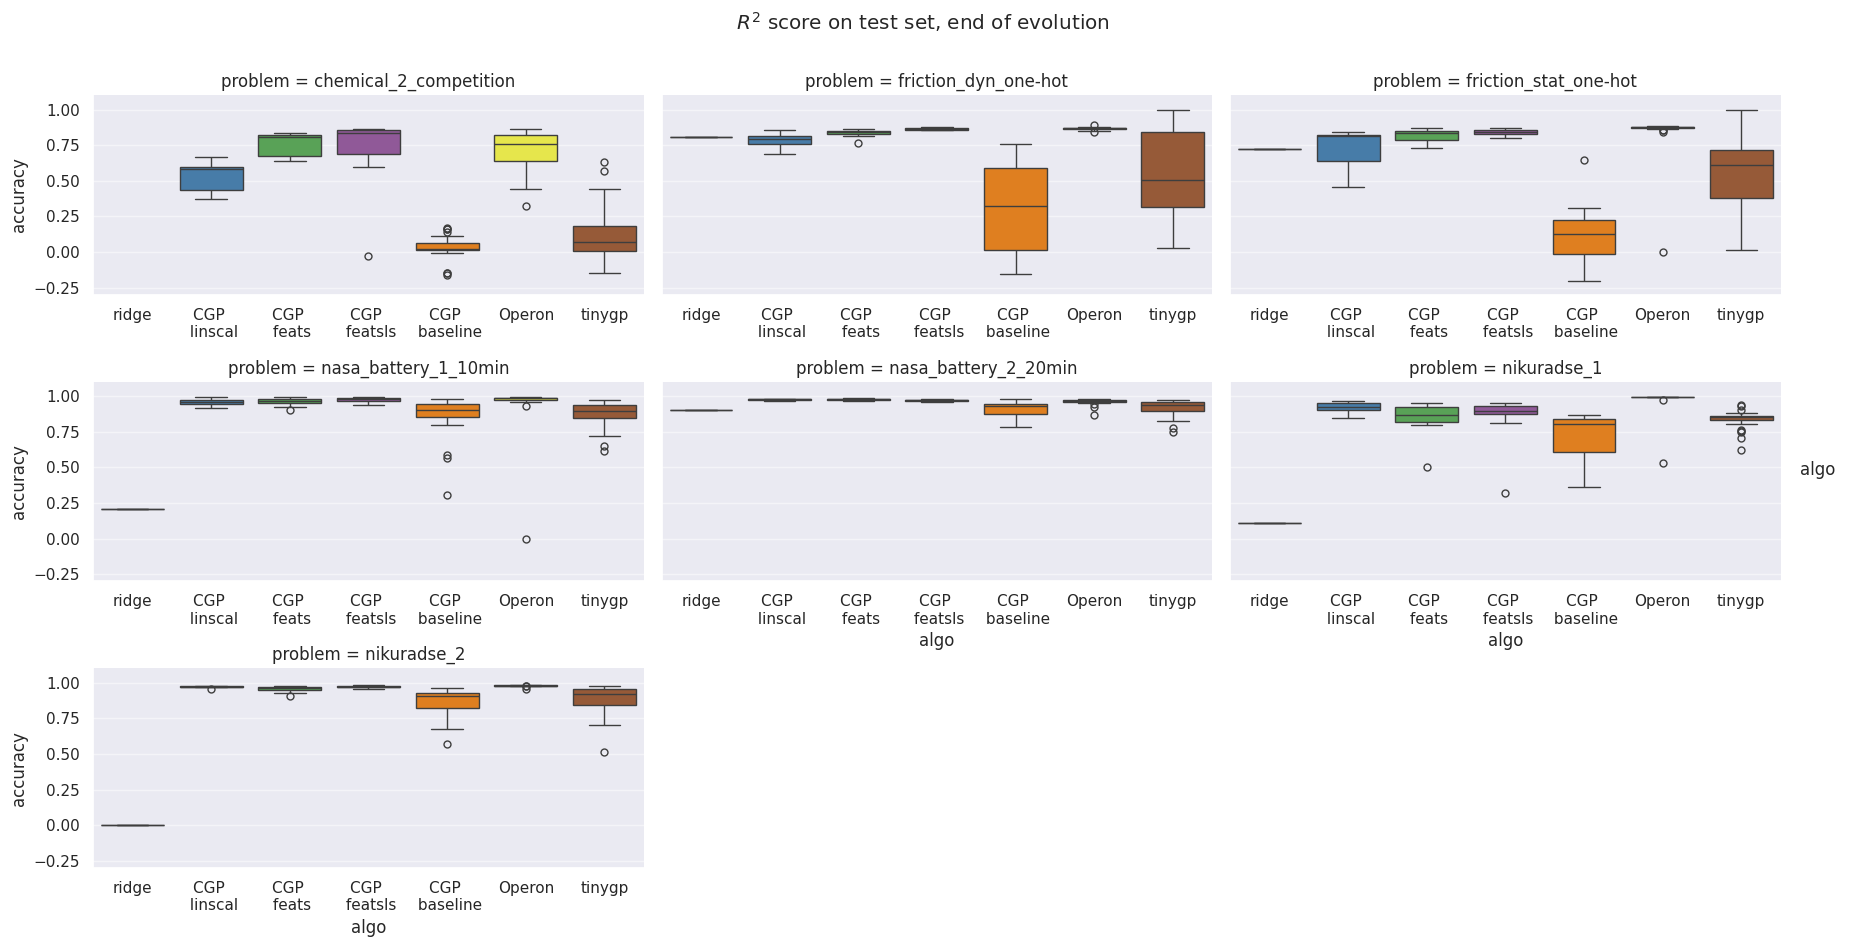

In [10]:
g = sns.catplot(x="algo", y="accuracy", hue="algo", data=final_df_and_baseline, col="problem", col_wrap=3,
                kind="box", palette="Set1", height=3, aspect=2, sharex=False)
g.figure.suptitle("$R^2$ score on test set, end of evolution", y=1.05)  # Add title above the plot
plt.ylim(-.3, 1.1)
plt.show()

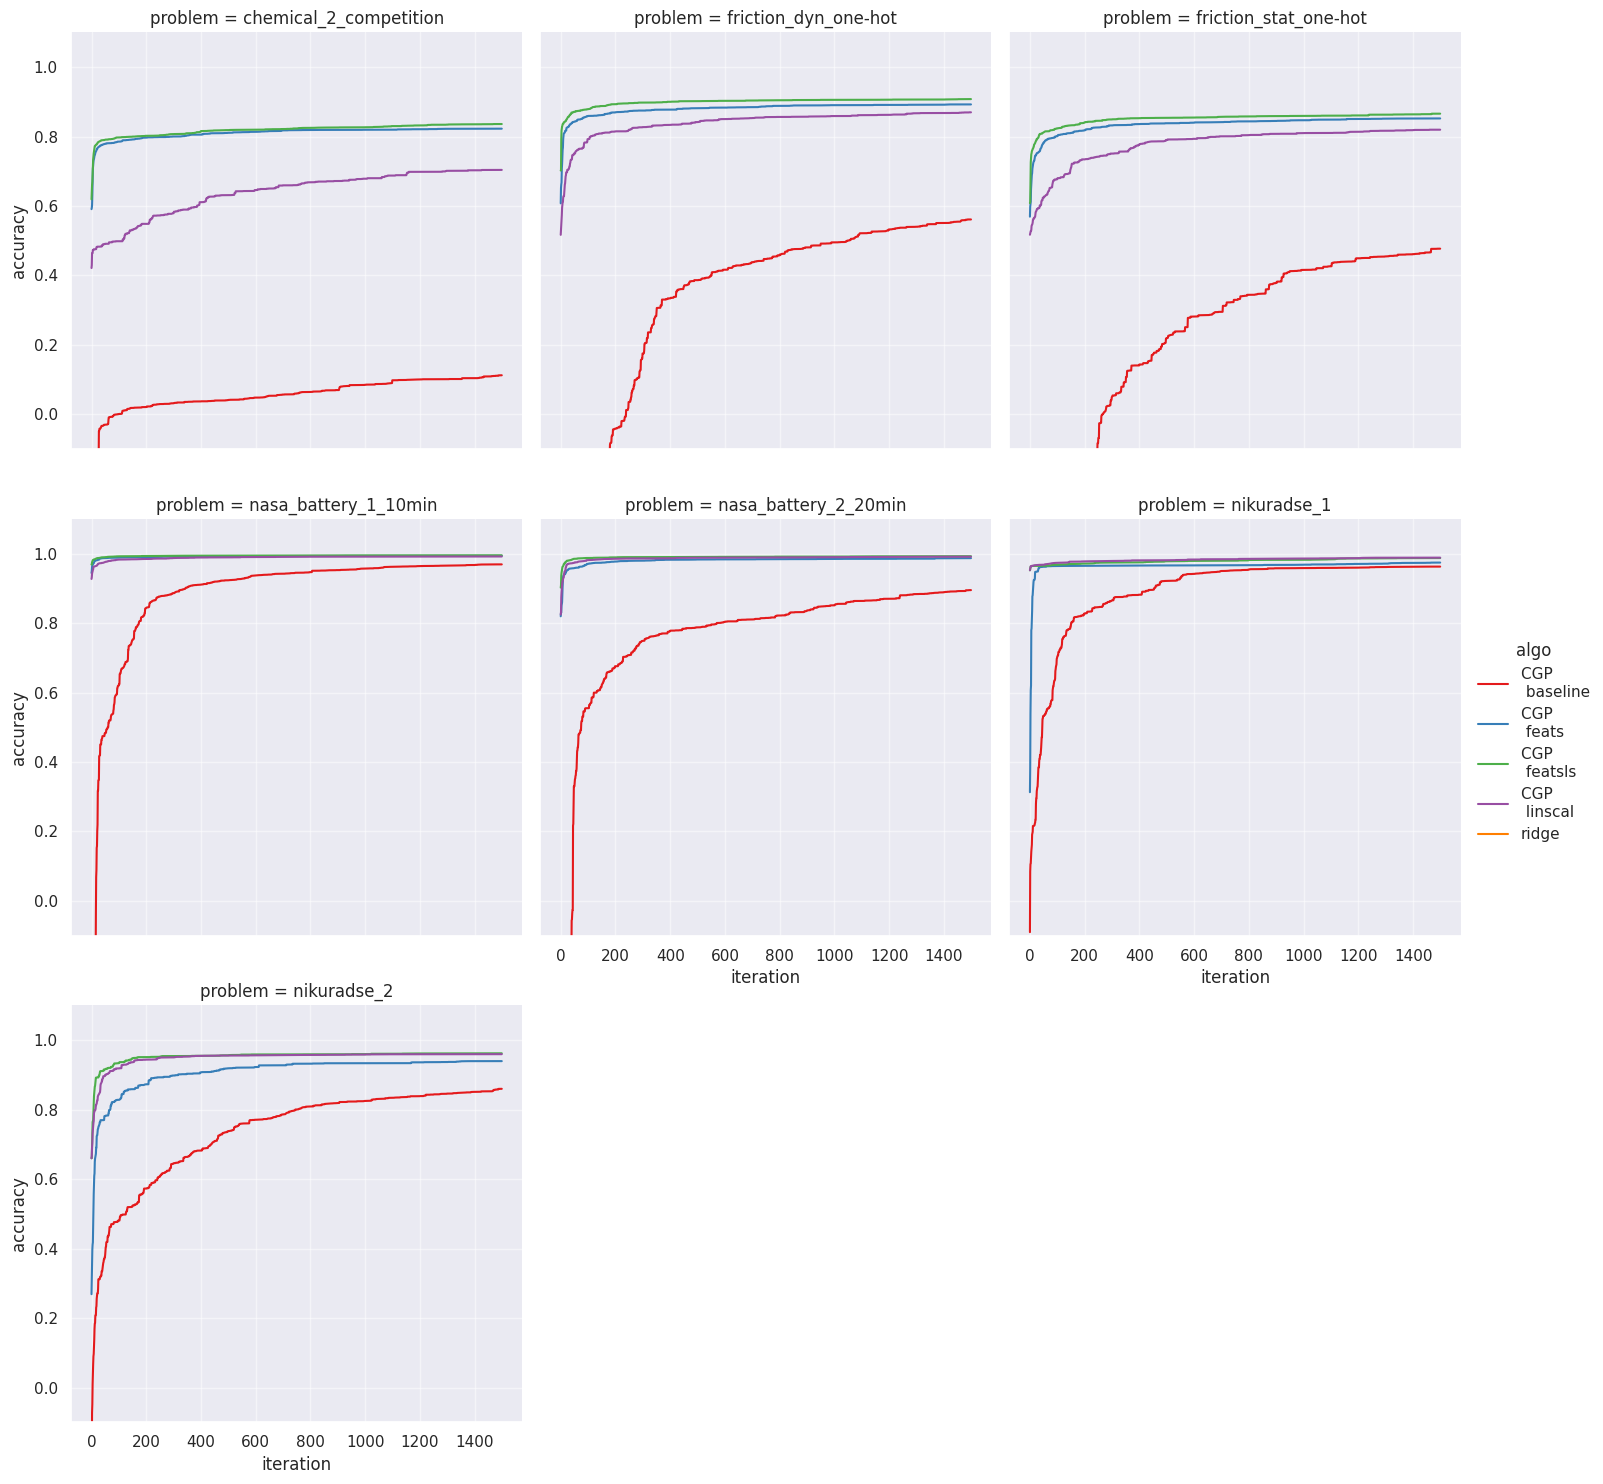

In [11]:
k = 50  # keep one point every 10 iterations

df_plot = (
    df[df["when"] == "train"]
    .groupby(["problem", "algo", "iteration"], as_index=False)
    .accuracy.mean()
)

sns.relplot(data=df_plot, x="iteration", y="accuracy", hue="algo", col_wrap=3,
            col="problem", errorbar=None, kind="line", palette="Set1")
plt.ylim(-.1, 1.1)
plt.show()

In [17]:
genome_sizes_df = pd.concat(
    [pd.read_csv("genome_analysis.csv"),
     pd.read_csv("genome_analysis_baseline.csv")],
    ignore_index=True
)
genome_sizes_df #.head()

,problem,seed,algo,size
0,chemical_2_competition,0,linscal,7
1,friction_dyn_one-hot,0,linscal,10
2,friction_stat_one-hot,0,linscal,15
3,nasa_battery_1_10min,0,linscal,13
4,nasa_battery_2_20min,0,linscal,15
...,...,...,...,...
415,friction_stat_one-hot,29,baseline,0
416,nasa_battery_1_10min,29,baseline,0
417,nasa_battery_2_20min,29,baseline,0
418,nikuradse_1,29,baseline,0


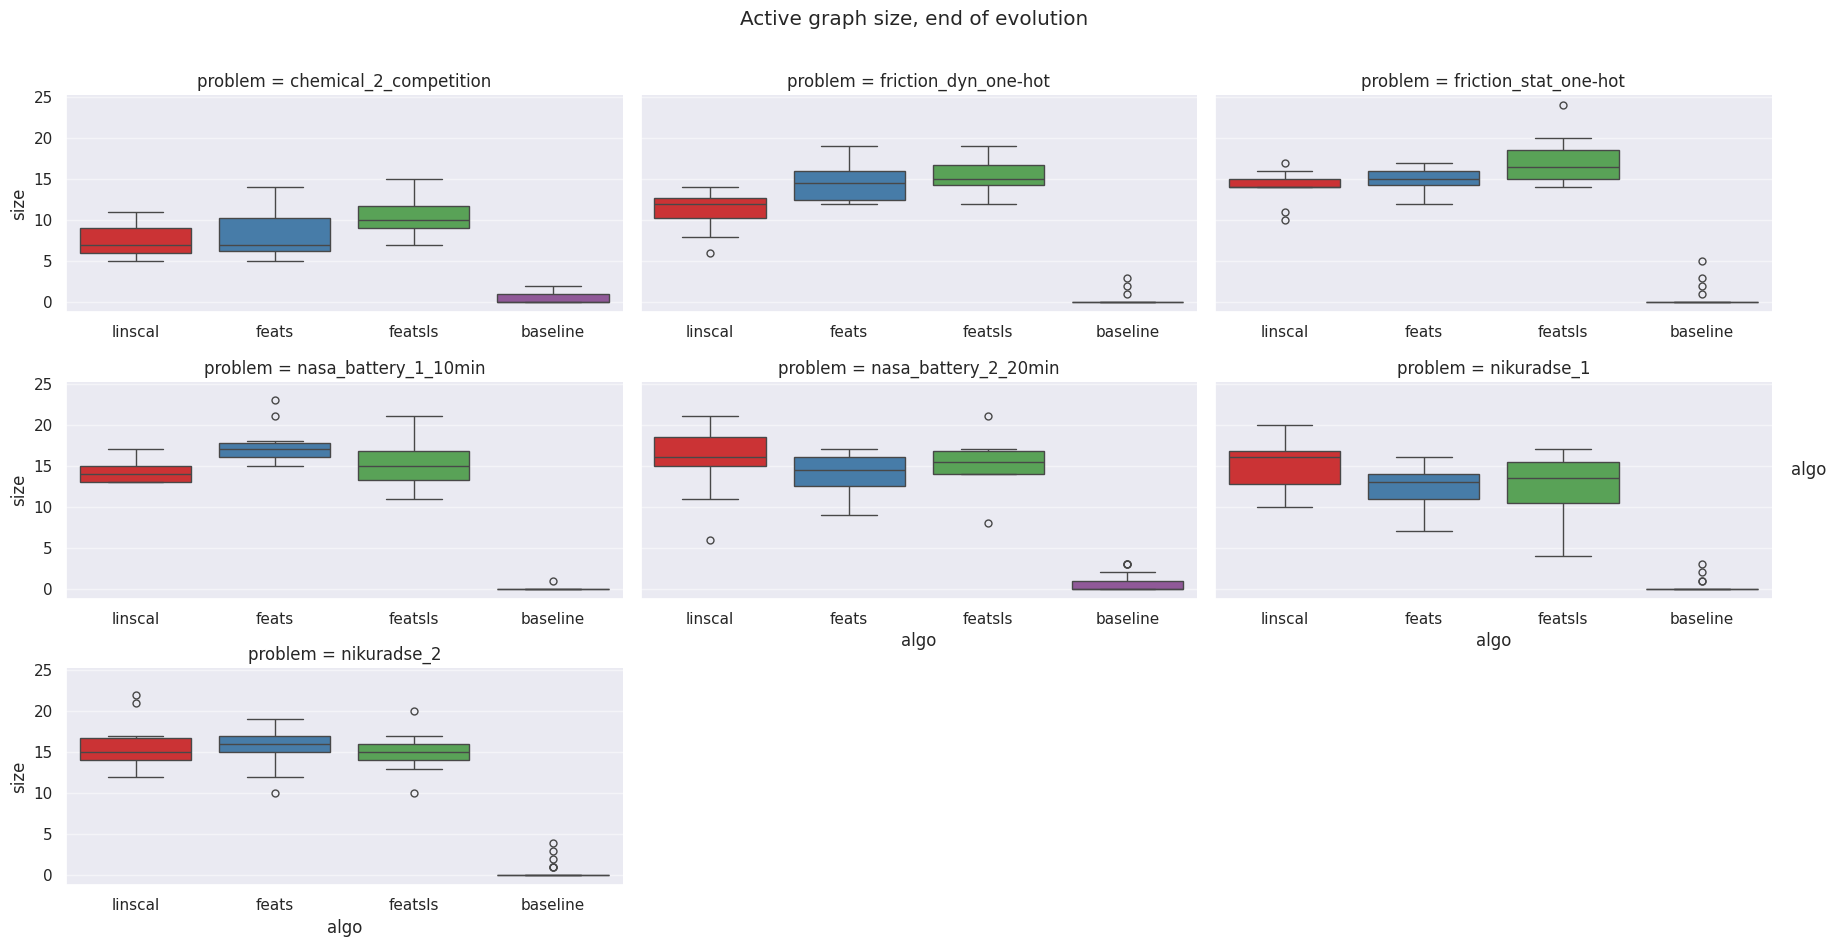

In [18]:
g = sns.catplot(x="algo", y="size", hue="algo", data=genome_sizes_df, col="problem", col_wrap=3,
                kind="box", palette="Set1", height=3, aspect=2, sharex=False)
g.figure.suptitle("Active graph size, end of evolution", y=1.05)  # Add title above the plot
# plt.ylim(-.3, 1.1)
plt.show()